In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Read SEC data for 2025 Q4
num_text_2025_q4 = pd.read_csv('2025q4/num.txt', sep='\t', low_memory=False)
num_text_2025_q4.head()

,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote
0,0000002488-25-000166,AccountsPayableCurrent,us-gaap/2025,20241231,0,USD,NaN,NaN,2.466000e+09,NaN
1,0000002488-25-000166,AccountsPayableCurrent,us-gaap/2025,20250930,0,USD,NaN,NaN,3.483000e+09,NaN
2,0000002488-25-000166,AccountsReceivableNetCurrent,us-gaap/2025,20241231,0,USD,NaN,NaN,6.192000e+09,NaN
3,0000002488-25-000166,AccountsReceivableNetCurrent,us-gaap/2025,20250930,0,USD,NaN,NaN,6.201000e+09,NaN
4,0000002488-25-000166,AccruedLiabilitiesCurrentAndNoncurrent,us-gaap/2025,20241231,0,USD,NaN,NaN,4.260000e+09,NaN


In [6]:
# Filter for Revenues
revenues_2025_q4 = num_text_2025_q4[num_text_2025_q4['tag'] == 'Revenues']
revenues_2025_q4.head()

,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote
1143,0000002969-25-000055,Revenues,us-gaap/2025,20230930,4,USD,NaN,NaN,1.260000e+10,NaN
1144,0000002969-25-000055,Revenues,us-gaap/2025,20230930,4,USD,BusinessSegments=AmericasSegment;Consolidation...,NaN,5.369300e+09,NaN
1145,0000002969-25-000055,Revenues,us-gaap/2025,20230930,4,USD,BusinessSegments=AmericasSegment;Consolidation...,NaN,2.225400e+09,NaN
1146,0000002969-25-000055,Revenues,us-gaap/2025,20230930,4,USD,BusinessSegments=AmericasSegment;Consolidation...,NaN,3.143900e+09,NaN
1147,0000002969-25-000055,Revenues,us-gaap/2025,20230930,4,USD,BusinessSegments=AmericasSegment;Consolidation...,NaN,0.000000e+00,NaN


In [7]:
# Bring in company information for context
company_info_2025q4 = pd.read_csv('2025q4/sub.txt', sep='\t', low_memory=False)
company_info_2025q4.head()

,adsh,cik,name,sic,countryba,stprba,cityba,zipba,bas1,bas2,...,period,fy,fp,filed,accepted,prevrpt,detail,instance,nciks,aciks
0,0000002488-25-000166,2488,ADVANCED MICRO DEVICES INC,3674.0,US,CA,SANTA CLARA,95054,2485 AUGUSTINE DRIVE,NaN,...,20250930,2025.0,Q3,20251105,2025-11-04 18:08:00.0,0,1,amd-20250927_htm.xml,1,NaN
1,0000002969-25-000055,2969,"AIR PRODUCTS & CHEMICALS, INC.",2810.0,US,PA,ALLENTOWN,18106-5500,1940 AIR PRODUCTS BLVD.,NaN,...,20250930,2025.0,FY,20251120,2025-11-20 10:21:00.0,0,1,apd-20250930_htm.xml,1,NaN
2,0000003499-25-000026,3499,ALEXANDERS INC,6798.0,US,NJ,PARAMUS,07652,210 ROUTE 4 EAST,NaN,...,20250930,2025.0,Q3,20251103,2025-11-03 08:42:00.0,0,1,alx-20250930_htm.xml,1,NaN
3,0000003545-25-000140,3545,"ALICO, INC.",100.0,US,FL,"FT. MYERS,",33913,10070 DANIELS INTERSTATE COURT STE. 100,NaN,...,20250930,2025.0,FY,20251124,2025-11-24 16:22:00.0,0,1,alco-20250930_htm.xml,1,NaN
4,0000003570-25-000107,3570,CHENIERE ENERGY INC,4924.0,US,TX,HOUSTON,77002,845 TEXAS AVENUE,SUITE 1250,...,20250930,2025.0,Q3,20251030,2025-10-29 17:36:00.0,0,1,lng-20250930_htm.xml,1,NaN


In [8]:
# Check columns to understand data structure
print(revenues_2025_q4.columns)
print(company_info_2025q4.columns)

Index(['adsh', 'tag', 'version', 'ddate', 'qtrs', 'uom', 'segments', 'coreg',
       'value', 'footnote'],
      dtype='str')
Index(['adsh', 'cik', 'name', 'sic', 'countryba', 'stprba', 'cityba', 'zipba',
       'bas1', 'bas2', 'baph', 'countryma', 'stprma', 'cityma', 'zipma',
       'mas1', 'mas2', 'countryinc', 'stprinc', 'ein', 'former', 'changed',
       'afs', 'wksi', 'fye', 'form', 'period', 'fy', 'fp', 'filed', 'accepted',
       'prevrpt', 'detail', 'instance', 'nciks', 'aciks'],
      dtype='str')


In [9]:
# Merge revenues with company info for analysis
revenues_merged = revenues_2025_q4.merge(
    company_info_2025q4[['adsh', 'cik', 'name', 'sic', 'cityba', 'stprba', 'countryba', 'form', 'period', 'filed']],
    on='adsh',
    how='left'
)

revenues_merged.head()

,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote,cik,name,sic,cityba,stprba,countryba,form,period,filed
0,0000002969-25-000055,Revenues,us-gaap/2025,20230930,4,USD,NaN,NaN,1.260000e+10,NaN,2969,"AIR PRODUCTS & CHEMICALS, INC.",2810.0,ALLENTOWN,PA,US,10-K,20250930,20251120
1,0000002969-25-000055,Revenues,us-gaap/2025,20230930,4,USD,BusinessSegments=AmericasSegment;Consolidation...,NaN,5.369300e+09,NaN,2969,"AIR PRODUCTS & CHEMICALS, INC.",2810.0,ALLENTOWN,PA,US,10-K,20250930,20251120
2,0000002969-25-000055,Revenues,us-gaap/2025,20230930,4,USD,BusinessSegments=AmericasSegment;Consolidation...,NaN,2.225400e+09,NaN,2969,"AIR PRODUCTS & CHEMICALS, INC.",2810.0,ALLENTOWN,PA,US,10-K,20250930,20251120
3,0000002969-25-000055,Revenues,us-gaap/2025,20230930,4,USD,BusinessSegments=AmericasSegment;Consolidation...,NaN,3.143900e+09,NaN,2969,"AIR PRODUCTS & CHEMICALS, INC.",2810.0,ALLENTOWN,PA,US,10-K,20250930,20251120
4,0000002969-25-000055,Revenues,us-gaap/2025,20230930,4,USD,BusinessSegments=AmericasSegment;Consolidation...,NaN,0.000000e+00,NaN,2969,"AIR PRODUCTS & CHEMICALS, INC.",2810.0,ALLENTOWN,PA,US,10-K,20250930,20251120


In [10]:
# Keep only consolidated totals (no segment breakdowns)
revenues_clean = revenues_merged[revenues_merged['segments'].isna()]

# Specify only annual data (qtrs = 4)
revenues_clean = revenues_clean[revenues_clean['qtrs'] == 4]

# Drop zeros and nulls
revenues_clean = revenues_clean[revenues_clean['value'] > 0].dropna(subset=['value'])

Use Benford's law to check if any company is suspicious

In [11]:
# Extract first digit
revenues_clean['first_digit'] = revenues_clean['value'].astype(str).str[0].astype(int)

# Compare actual vs expected Benford distribution
benford_expected = {1: 30.1, 2: 17.6, 3: 12.5, 4: 9.7, 5: 7.9, 6: 6.7, 7: 5.8, 8: 5.1, 9: 4.6}
actual_dist = revenues_clean['first_digit'].value_counts(normalize=True).sort_index() * 100

In [ ]:
# Manipulate numbers for comparison
actual_counts = revenues_clean['first_digit'].value_counts().sort_index()
actual_pct = (actual_counts / actual_counts.sum() * 100).round(2)

# Create a DataFrame for comparison
benford_df = pd.DataFrame({
    'digit': list(benford_expected.keys()),
    'expected_pct': list(benford_expected.values()),
    'actual_pct': actual_pct.values
})

# Calculate deviation
benford_df['deviation'] = (benford_df['actual_pct'] - benford_df['expected_pct']).round(2)
benford_df

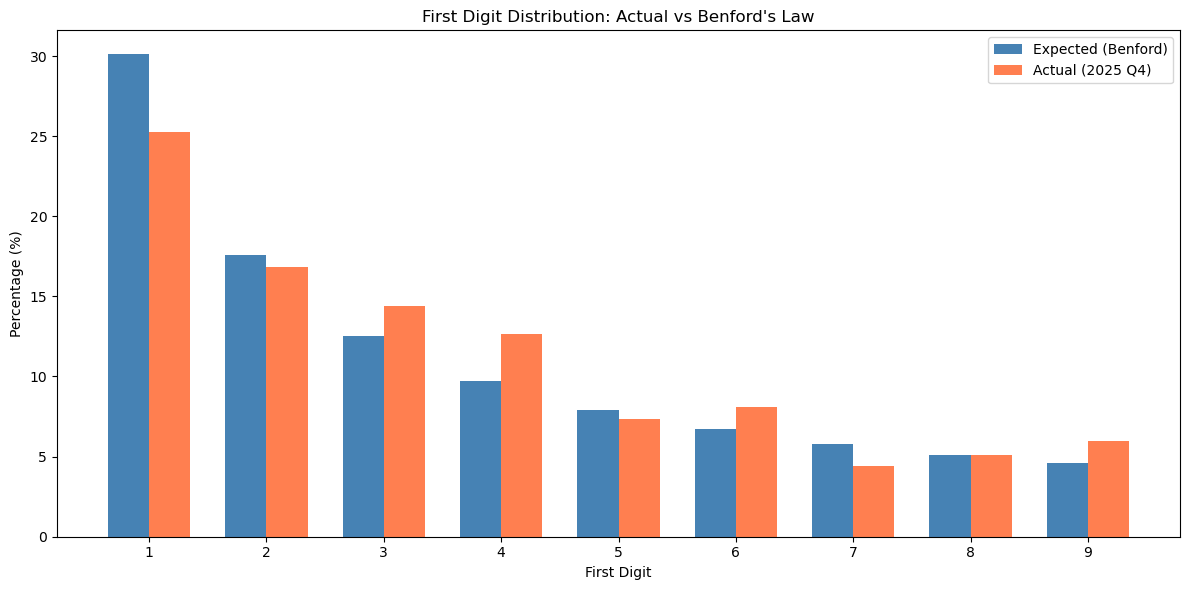

In [ ]:
import numpy as np

# Plotting the distributions
x = np.arange(len(benford_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, benford_df['expected_pct'], width, label='Expected (Benford)', color='steelblue')
ax.bar(x + width/2, benford_df['actual_pct'], width, label='Actual (2025 Q4)', color='coral')
ax.set_title("First Digit Distribution: Actual vs Benford's Law")
ax.set_xlabel('First Digit')
ax.set_ylabel('Percentage (%)')
ax.set_xticks(x)
ax.set_xticklabels(benford_df['digit'])
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
from scipy import stats

# Calculate z-scores for outlier detection
revenues_clean['zscore'] = revenues_clean.groupby('sic')['value'].transform(
    lambda x: stats.zscore(x, nan_policy='omit')
)

# Flag outliers based on z-score threshold (e.g., |z| > 3)
revenues_clean['outlier_flag'] = revenues_clean['zscore'].abs() > 3

/var/folders/pm/5ywb110d5x17h6m3fvnh3ynr0000gn/T/ipykernel_25161/2079528232.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  lambda x: stats.zscore(x, nan_policy='omit')


In [14]:
# Display outliers
outliers = revenues_clean[revenues_clean['outlier_flag'] == True][['name', 'sic', 'value', 'zscore']].sort_values('zscore', ascending=False)
print(f"{len(outliers)} companies flagged")
outliers.head(20)

2 companies flagged


,name,sic,value,zscore
11036,INTUIT INC.,7372.0,1.883100e+10,3.631203
11033,INTUIT INC.,7372.0,1.628500e+10,3.096913


In [15]:
# Check for duplicate revenue figures (same company, same value)
revenues_clean['duplicate_flag'] = revenues_clean.duplicated(
    subset=['name', 'value'], keep=False
)

# Display duplicate revenue figures
duplicates = revenues_clean[revenues_clean['duplicate_flag'] == True][
    ['name', 'sic', 'value', 'ddate']
].sort_values(['name', 'value'])

print(f"{len(duplicates)} duplicate revenue figures found")
duplicates.head(20)

105 duplicate revenue figures found


,name,sic,value,ddate
20748,3 E NETWORK TECHNOLOGY GROUP LTD,7371.0,37130.0,20230630
20927,3 E NETWORK TECHNOLOGY GROUP LTD,7371.0,37130.0,20230630
21064,3 E NETWORK TECHNOLOGY GROUP LTD,7371.0,37130.0,20230630
20749,3 E NETWORK TECHNOLOGY GROUP LTD,7371.0,859344.0,20240630
20928,3 E NETWORK TECHNOLOGY GROUP LTD,7371.0,859344.0,20240630
21065,3 E NETWORK TECHNOLOGY GROUP LTD,7371.0,859344.0,20240630
20750,3 E NETWORK TECHNOLOGY GROUP LTD,7371.0,4835167.0,20250630
20929,3 E NETWORK TECHNOLOGY GROUP LTD,7371.0,4835167.0,20250630
21066,3 E NETWORK TECHNOLOGY GROUP LTD,7371.0,4835167.0,20250630
27363,"ABPRO HOLDINGS, INC.",2836.0,122000.0,20231231


In [16]:
# Finalize dataset by removing duplicates (keep first occurrence)
revenues_clean = revenues_clean.sort_values('filed', ascending=False)
revenues_final = revenues_clean.drop_duplicates(subset=['name', 'ddate', 'value'], keep='first')

# Display row counts before and after deduplication
print(f"Rows before: {len(revenues_clean)}")
print(f"Rows after: {len(revenues_final)}")

Rows before: 570
Rows after: 514


In [18]:
# Save cleaned datasets for future use
revenues_clean.to_csv('revenues_clean.csv', index=False)
revenues_final.to_csv('revenues_final.csv', index=False)
benford_df.to_csv('benford_comparison.csv', index=False)
outliers.to_csv('outliers.csv', index=False)
duplicates.to_csv('duplicates.csv', index=False)